# Week 13: Tables, NumPy and Plotting — PHASE 3: Build a checkable report

*📚 Computer Programming I · ⏱️ 5 Hours · 👨‍🏫 Dr. Arif Solmaz*

## Summarise a whole table at once

Last week we saved a report as a file that another person can open and check. The numbers inside that file usually form a table. Looping over every cell works, but each new question needs a new loop.

A log holds four time steps for three temperature sensors. We want the mean of each sensor, the number of readings above 24.0 °C, and a plot that shows where they happen.

**Try this first — before code.** Sketch the 4-row, 3-column temperature table. Circle one column. Which direction does a per-sensor mean travel: down a column or across a row?

**Why this week's tool?** A NumPy array knows its shape. One expression applies to every element, and axis=0 collapses the rows into one value per column. A Boolean mask counts readings above a limit. matplotlib turns the same array into a picture.

**By the end.** Explain the shape of the array. State which axis a per-sensor mean uses. Match the count of hot readings to the points that stand out in the plot.


## Explain the program: An array operation applies to every element at once

np.array(temps) stores a table with a shape of rows × columns. An expression such as a * 0.001 or a > 24.0 is applied to every element. No loop is written. A mask is an array of True/False with the same shape as the data. axis=0 collapses the rows into one value per column.

**Draw or trace.** Draw [[22.1, 21.8], [24.5, 23.0], [25.2, 23.5]] as three rows and two columns. Beside it draw the mask a > 24.0 with the same shape.

**Predict before running.** How many True cells does the mask have? What does np.mean(a, axis=0) return: two values or three?

<details><summary>Trace and explanation — after your prediction</summary>

1. Row 0: 22.1 and 21.8 are both False.
2. Row 1: 24.5 is True, 23.0 is False; row 2: 25.2 is True, 23.5 is False.
3. axis=0 collapses the three rows, so the mean has two values, one per column.

The mask has two True cells, both in column 0. The mean has two values: 23.93 and 22.77. mask.sum() gives 2 and a[mask] gives [24.5, 25.2]. Every element was tested by one expression.

</details>

**Change one thing.** Change the comparison to >= 24.5 and predict the count. Then compute the mean with axis=1 and explain why three values appear.

**Türkçe:** Bir dizi işlemi her elemana aynı anda uygulanır. Şekil satır × sütun sayısıdır; maske aynı şekilde True/False dizisidir ve axis=0 satırları toplayıp sütun başına tek değer bırakır.


<details><summary>Learning objectives</summary>

## 🎯 Learning Objectives

By the end of this week, you will be able to:

- Store a table of readings as a list of lists and reach one cell with `grid[row][col]`
- Create a NumPy array and read its `shape` and `dtype`
- Select a row, a column or a block with `a[row, col]` and slices
- Apply arithmetic and statistics to a whole array with `axis=0` or `axis=1`
- Count and select readings with a Boolean mask
- Load numeric CSV data into an array with plain Python or `np.loadtxt`
- Draw a labelled line plot with matplotlib and save it as a PNG file
- Read a plot as evidence and confirm what it shows with a number

</details>


<details><summary>Class participation and assessment</summary>

---
## 🤝 Engineering Learning Contract

- **Professional relevance:** examples and core exercises model the data, sensing, automation, numerical, and decision tasks used in engineering engineering.
- **Interaction:** predict before running, compare reasoning with a partner, and ask whenever a step is unclear; scheduled checkpoints guarantee question time.
- **Assessment alignment:** worked examples and Core Exercises 1–8 rehearse the same reasoning operations used on exams—trace, implement, debug, interpret, and justify—while exam values and contexts may change.
- **Assessment:** Assessment consists only of the midterm exam (50%) and final exam (50%). Weekly notebooks, exercises, projects, demonstrations and presentations are ungraded practice; no weekly submission is required.

</details>


<details><summary>Class schedule and checkpoints</summary>

---
## 🧭 Five-Hour Class Roadmap

This notebook is designed for one five-hour class with four short breaks.

| Target | Activity |
|---|---|
| 00:00–00:55 | Concepts and examples → Checkpoint 1 |
| 00:55–01:05 | Break |
| 01:05–01:55 | Concepts and examples → Checkpoint 2 |
| 01:55–02:05 | Break |
| 02:05–02:55 | Concepts and examples → Checkpoint 3 |
| 02:55–03:05 | Break |
| 03:05–03:55 | Concepts and examples → Checkpoint 4 |
| 03:55–04:05 | Break |
| 04:05–04:45 | Core Practice (Exercises 1–8) → Checkpoint 5 |
| 04:45–05:00 | Review and retry failed checks |

Concept checkpoints compare your predictions with an expected answer. Checkpoint 5 is your practice reflection. No grading submission is sent by these tools. Save the notebook to keep your work. Exercises 9 and above are optional extensions.

</details>


In [ ]:
#@title Study tools — run this cell once (the code is hidden; you do not need to read it)
# These small tools give local study feedback.
_checkpoint_results = {}

def check_answer(number, answer, expected, explanation):
    actual = str(answer).strip().lower().replace(" ", "")
    target = str(expected).strip().lower().replace(" ", "")
    correct = actual == target
    _checkpoint_results[int(number)] = ("Concept check", int(correct), 1)
    if correct:
        print(f"Checkpoint {number}: correct. {explanation}")
    elif not str(answer).strip():
        print(f"Checkpoint {number}: enter your prediction, then run again.")
    else:
        print(f"Checkpoint {number}: review the example and try again.")
    return correct

def record_checkpoint(number, checks):
    """Report each concrete concept check used by the introductory notebook."""
    passed = sum(bool(correct) for _, correct in checks)
    _checkpoint_results[int(number)] = ("Concept checks", passed, len(checks))
    print(f"Checkpoint {number}: {passed}/{len(checks)} concept checks match.")
    for label, correct in checks:
        print(("OK: " if correct else "Review: ") + label)
    return passed, len(checks)

def exercise_checkpoint(number, practiced, expected=8):
    """Summarize an explicit self-report; this does not grade your code."""
    if not isinstance(practiced, (list, tuple, set)):
        _checkpoint_results.pop(int(number), None)
        print("Use a list of exercise numbers, for example [1, 2].")
        return 0, expected
    if any(type(item) is not int or not 1 <= item <= expected for item in practiced):
        _checkpoint_results.pop(int(number), None)
        print(f"Use whole exercise numbers from 1 to {expected}.")
        return 0, expected
    done = set(practiced)
    _checkpoint_results[int(number)] = ("Practice self-report", len(done), expected)
    print(f"Practice self-report: {len(done)}/{expected} core exercises reviewed.")
    print("This is your reflection, not a correctness score or a grade.")
    remaining = [str(i) for i in range(1, expected + 1) if i not in done]
    if remaining:
        print("Still to review:", ", ".join(remaining))
    print("For each exercise: test the result, explain the steps, then compare with the worked solution.")
    return len(done), expected

def show_progress_summary():
    print("\nMy study feedback (this runtime)")
    for number in range(1, 6):
        if number in _checkpoint_results:
            kind, count, total = _checkpoint_results[number]
            print(f"{number}. {kind}: {count}/{total}")
        else:
            print(f"{number}. Not run yet")
    print("These checks send no grading submission. Save your notebook to keep your work.")

print("Local study tools ready.")


---

## Part 1: A table as a list of lists

A sensor log is a **table**: one row per time step, one column per sensor. In plain Python a table is a **list of lists**. Each inner list is one row.

| Time | Sensor A | Sensor B | Sensor C |
|---|---|---|---|
| 00:00 | 22.1 | 21.8 | 22.4 |
| 00:05 | 22.3 | 21.9 | 22.6 |
| 00:10 | 22.6 | 22.0 | 22.9 |
| … | … | … | … |

`grid[row][col]` picks a row first, then one value inside that row. Both indices start at 0.


**Figure 1.1: Building the table and reaching one cell**

In [2]:
temps = [  # rows = every 5 minutes, columns = sensors A, B, C
    [22.1, 21.8, 22.4],
    [22.3, 21.9, 22.6],
    [22.6, 22.0, 22.9],
    [22.9, 22.2, 23.1],
    [23.4, 22.5, 23.5],
    [23.8, 22.7, 23.9],
    [24.1, 22.9, 24.2],
    [24.5, 23.0, 24.6],
    [24.7, 23.2, 24.8],
    [24.9, 23.3, 25.0],
    [25.0, 23.4, 25.1],
    [25.2, 23.5, 25.3],
]

print("Rows (time steps):", len(temps))
print("Columns (sensors):", len(temps[0]))
print("Row 1:", temps[1])
print("Row 1, column 2:", temps[1][2])


Rows (time steps): 12
Columns (sensors): 3
Row 1: [22.3, 21.9, 22.6]
Row 1, column 2: 22.6


A **row** is easy: `for row in temps:` visits each time step. A **column** is harder. There is no list for a column, so you loop over the rows and collect `row[col]` each time.


**Figure 1.2: Row statistics and column statistics with loops**

In [3]:
# Row loop: mean of the three sensors at each time step (first 3 rows)
for i in range(3):
    row = temps[i]
    print(f"t = {i * 5:2d} min  mean = {sum(row) / len(row):.2f} C")

# Column loop: mean of one sensor over all time steps
for col in range(3):
    total = 0.0
    for row in temps:
        total += row[col]
    print(f"Sensor {col}: mean = {total / len(temps):.2f} C")


t =  0 min  mean = 22.10 C
t =  5 min  mean = 22.27 C
t = 10 min  mean = 22.50 C
Sensor 0: mean = 23.79 C
Sensor 1: mean = 22.70 C
Sensor 2: mean = 23.95 C


> 💡 **Note:** This works, but every question needs a new loop. A column mean is five lines. A real log with 10,000 rows and 30 columns would need many slow loops. **NumPy** does the looping for you.


---

## Part 2: NumPy arrays

`import numpy as np` loads the numerical library. `np.array(temps)` turns the list of lists into an **array**. An array has:

- a `shape`: `(rows, columns)`,
- one `dtype`: every value has the same type (here `float64`).

Indexing uses **one pair of brackets** with a comma: `a[1, 2]` is row 1, column 2. A colon means "all": `a[:, 0]` is the whole column 0 and `a[0, :]` is the whole row 0.


**Figure 2.1: From a list of lists to an array**

In [4]:
import numpy as np

a = np.array(temps)
print("Type:", type(a).__name__)
print("Shape:", a.shape)
print("Rows, columns:", a.shape[0], a.shape[1])
print("dtype:", a.dtype)
print("First two rows:")
print(a[:2])


Type: ndarray
Shape: (12, 3)
Rows, columns: 12 3
dtype: float64
First two rows:
[[22.1 21.8 22.4]
 [22.3 21.9 22.6]]


**Figure 2.2: Indexing and slicing an array**

In [5]:
print("a[1, 2]  ->", a[1, 2])          # row 1, column 2
print("a[0, :]  ->", a[0, :])          # row 0, all columns
print("a[:, 0]  ->", a[:, 0])          # all rows, column 0 (sensor A)
print("a[2:5, 1] ->", a[2:5, 1])       # rows 2, 3, 4 of sensor B
print("Last row ->", a[-1, :])


a[1, 2]  -> 22.6
a[0, :]  -> [22.1 21.8 22.4]
a[:, 0]  -> [22.1 22.3 22.6 22.9 23.4 23.8 24.1 24.5 24.7 24.9 25.  25.2]
a[2:5, 1] -> [22.  22.2 22.5]
Last row -> [25.2 23.5 25.3]


> 💡 **Note:** `a[:, 0]` gives the column in one step. In Part 1 the same column needed a loop. The array **knows its shape**, so NumPy can find every column value without your help.


---
### ⏱️ Checkpoint 1 of 5 — Shape (target 00:55)

For `a = np.array([[1, 2, 3, 4], [5, 6, 7, 8], [9, 10, 11, 12]])`, what is `a.shape[1]`?

Enter a short answer in the next cell and run it. Retry after reviewing the
preceding examples if needed.


In [6]:
checkpoint_1_answer = ""  # enter your answer
check_answer(
    1, checkpoint_1_answer, '4',
    'Shape is (rows, columns); index 1 is the column count.',
)


Checkpoint 1: enter your prediction, then run again.


False

---

## Part 3: Arithmetic on a whole array

`a * 0.001` multiplies **every** element. No loop is written. This is called **vectorised** arithmetic. `a + b`, `a - b` and `a / b` work the same way when the shapes match.

Statistics also work on the whole array or along one direction:

| Call | Result |
|---|---|
| `np.mean(a)` | one number, all values |
| `np.mean(a, axis=0)` | one value **per column** (down the rows) |
| `np.mean(a, axis=1)` | one value **per row** (across the columns) |

`np.min`, `np.max`, `np.sum` and `np.std` take the same `axis` argument.


**Figure 3.1: Converting a whole column of units**

In [7]:
load_n = [0, 100, 200, 300, 400, 500]
deflection_mm = [0.00, 0.42, 0.85, 1.27, 1.70, 2.12]

deflection_m = np.array(deflection_mm) * 0.001   # mm -> m for every value
print("mm:", deflection_mm)
print("m: ", deflection_m)
print("Stiffness estimate (N/mm):", np.array(load_n[1:]) / np.array(deflection_mm[1:]))


mm: [0.0, 0.42, 0.85, 1.27, 1.7, 2.12]
m:  [0.      0.00042 0.00085 0.00127 0.0017  0.00212]
Stiffness estimate (N/mm): [238.0952381  235.29411765 236.22047244 235.29411765 235.8490566 ]


**Figure 3.2: Statistics per sensor and per time step**

In [8]:
print("Overall mean:", f"{np.mean(a):.2f}")
print("Per sensor (axis=0):")
print("  mean:", np.round(np.mean(a, axis=0), 2))
print("  min: ", np.min(a, axis=0))
print("  max: ", np.max(a, axis=0))
print("  std: ", np.round(np.std(a, axis=0), 2))
print("Per time step (axis=1), first 4:", np.round(np.mean(a, axis=1)[:4], 2))


Overall mean: 23.48
Per sensor (axis=0):
  mean: [23.79 22.7  23.95]
  min:  [22.1 21.8 22.4]
  max:  [25.2 23.5 25.3]
  std:  [1.06 0.58 0.99]
Per time step (axis=1), first 4: [22.1  22.27 22.5  22.73]


> 💡 **Note:** `axis=0` means "the result no longer has axis 0 (rows)". Twelve rows collapse into one value per column. If you want one value per sensor, use `axis=0`.


---
### ⏱️ Checkpoint 2 of 5 — Axis (target 01:55)

Rows are time steps and columns are sensors. Which `axis` value gives one mean per sensor?

Enter a short answer in the next cell and run it. Retry after reviewing the
preceding examples if needed.


In [9]:
checkpoint_2_answer = ""  # enter your answer
check_answer(
    2, checkpoint_2_answer, '0',
    'axis=0 collapses the rows and leaves one value per column.',
)


Checkpoint 2: enter your prediction, then run again.


False

---

## Part 4: Boolean masks

`current > 4.0` compares **every** element and returns an array of `True` and `False` with the same shape. This array is a **mask**.

- `mask.sum()` counts the `True` values (`True` counts as 1).
- `current[mask]` keeps only the values where the mask is `True`.
- `np.where(mask)[0]` gives the **positions** of the `True` values.
- `np.where(mask, x, y)` builds a new array: `x` where `True`, `y` elsewhere.


**Figure 4.1: Counting out-of-tolerance readings**

In [10]:
time_s = [0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5,
          5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5]
current_a = [2.0, 2.1, 2.0, 2.2, 2.1, 2.0, 2.3, 2.1, 2.2, 2.0,
             2.1, 2.2, 2.0, 2.1, 6.5, 2.2, 2.1, 2.0, 2.2, 2.1]

t = np.array(time_s)
current = np.array(current_a)
limit = 4.0

mask = current > limit
print("Mask:", mask)
print("Readings above limit:", mask.sum())
print("Values above limit:", current[mask])
positions = np.where(mask)[0]
print("Positions:", positions.tolist(), "-> times (s):", t[positions].tolist())


Mask: [False False False False False False False False False False False False
 False False  True False False False False False]
Readings above limit: 1
Values above limit: [6.5]
Positions: [14] -> times (s): [7.0]


**Figure 4.2: Masks on a table and `np.where` with two choices**

In [11]:
# How many readings per sensor are above 24.0 C?
hot = a > 24.0
print("Above 24.0 C per sensor:", hot.sum(axis=0))
print("Time steps where any sensor is hot:", np.where(hot.any(axis=1))[0])

# Replace the spike with the limit value, keep everything else
clipped = np.where(current > limit, limit, current)
print("Clipped current:", clipped)


Above 24.0 C per sensor: [6 0 6]
Time steps where any sensor is hot: [ 6  7  8  9 10 11]
Clipped current: [2.  2.1 2.  2.2 2.1 2.  2.3 2.1 2.2 2.  2.1 2.2 2.  2.1 4.  2.2 2.1 2.
 2.2 2.1]


---
### ⏱️ Checkpoint 3 of 5 — Masks (target 02:55)

What does `np.array([50, 70])[1] > 60` evaluate to? Answer true or false.

Enter a short answer in the next cell and run it. Retry after reviewing the
preceding examples if needed.


In [12]:
checkpoint_3_answer = ""  # enter your answer
check_answer(
    3, checkpoint_3_answer, 'true',
    'Index 1 is 70; 70 > 60 is True.',
)


Checkpoint 3: enter your prediction, then run again.


False

---

## Part 5: From a CSV file to an array

Last week you read a file with `open`, `split(",")` and `float`. The same code builds a list of lists. `np.array` finishes the job. NumPy also has a shortcut, `np.loadtxt`, for files that contain only numbers.

We write the file first, so the example runs anywhere.


**Figure 5.1: Writing the temperature log as a CSV file**

In [13]:
with open("temps.csv", "w") as file:
    file.write("sensor_a,sensor_b,sensor_c\n")
    for row in temps:
        file.write(f"{row[0]},{row[1]},{row[2]}\n")

with open("temps.csv", "r") as file:
    print(file.read()[:80] + "...")


sensor_a,sensor_b,sensor_c
22.1,21.8,22.4
22.3,21.9,22.6
22.6,22.0,22.9
22.9,22....


**Figure 5.2: Reading it back with plain Python, then `np.array`**

In [14]:
rows = []
with open("temps.csv", "r") as file:
    header = file.readline().strip().split(",")
    for line in file:
        parts = line.strip().split(",")
        rows.append([float(p) for p in parts])

data = np.array(rows)
print("Header:", header)
print("Shape:", data.shape, "dtype:", data.dtype)
print("Same as the original table:", np.array_equal(data, a))


Header: ['sensor_a', 'sensor_b', 'sensor_c']
Shape: (12, 3) dtype: float64
Same as the original table: True


**Figure 5.3: The shortcut `np.loadtxt`**

In [15]:
data2 = np.loadtxt("temps.csv", delimiter=",", skiprows=1)
print("Shape:", data2.shape)
print("Column means:", np.round(data2.mean(axis=0), 2))
print("Same as the plain-Python version:", np.array_equal(data, data2))


Shape: (12, 3)
Column means: [23.79 22.7  23.95]
Same as the plain-Python version: True


> 💡 **Note:** `np.loadtxt` stops with an error on a blank value or the word `abc`. The plain-Python loop from Week 12 lets you decide what to do with a bad line. Use the shortcut for clean files, the loop for messy ones.


---

## Part 6: Plotting with matplotlib

`import matplotlib.pyplot as plt` loads the plotting library. `plt.plot(x, y)` draws a line through the points. Every engineering plot needs:

- `plt.xlabel(...)` and `plt.ylabel(...)` **with units**,
- `plt.title(...)`,
- `plt.grid(True)` so values can be read.

A second `plt.plot` on the same figure adds a second line. Give each line a `label=` and call `plt.legend()`. `plt.savefig("plot.png")` writes the picture to a file, just as `open(..., "w")` wrote text last week. `plt.show()` displays it in the notebook.


**Figure 6.1: One signal against time**

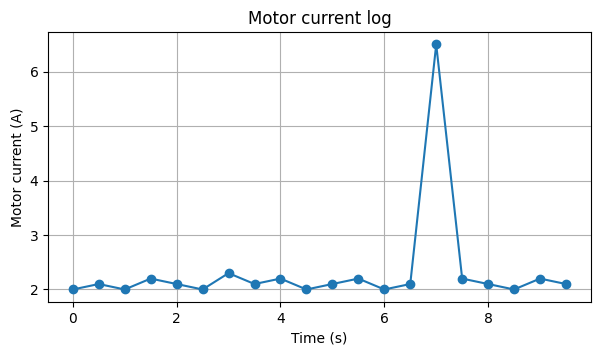

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 3.5))
plt.plot(t, current, marker="o")
plt.xlabel("Time (s)")
plt.ylabel("Motor current (A)")
plt.title("Motor current log")
plt.grid(True)
plt.savefig("current.png")
plt.show()


**Figure 6.2: Three sensors on one figure, saved as a PNG**

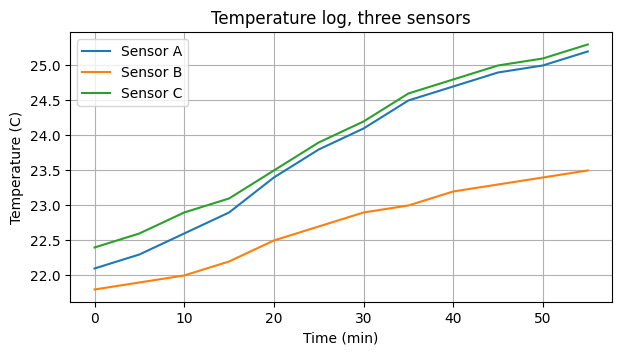

File exists: True
File size > 0: True


In [17]:
import os

minutes = np.arange(0, 60, 5)          # 0, 5, ..., 55
plt.figure(figsize=(7, 3.5))
plt.plot(minutes, a[:, 0], label="Sensor A")
plt.plot(minutes, a[:, 1], label="Sensor B")
plt.plot(minutes, a[:, 2], label="Sensor C")
plt.xlabel("Time (min)")
plt.ylabel("Temperature (C)")
plt.title("Temperature log, three sensors")
plt.grid(True)
plt.legend()
plt.savefig("temps.png")
plt.show()

print("File exists:", os.path.exists("temps.png"))
print("File size > 0:", os.path.getsize("temps.png") > 0)


---
### ⏱️ Checkpoint 4 of 5 — Saving (target 03:55)

Which `plt` function writes the figure to a PNG file?

Enter a short answer in the next cell and run it. Retry after reviewing the
preceding examples if needed.


In [18]:
checkpoint_4_answer = ""  # enter your answer
check_answer(
    4, checkpoint_4_answer, 'savefig',
    'savefig writes the figure to disk; show only displays it.',
)


Checkpoint 4: enter your prediction, then run again.


False

---

## Part 7: Reading a plot

Look at Figure 6.1. One point rises far above the others: a **spike**. The mask in Part 4 counted one reading above 4 A, at t = 7.0 s. The picture and the number agree.

A plot is **evidence, not proof**. It shows that one sample was high. It does not say *why*: a real overload, a loose wire and a sampling error all look the same. A checkable report gives both the picture and the number behind it, with the threshold stated.


**Figure 7.1: The plot and the count in one report**

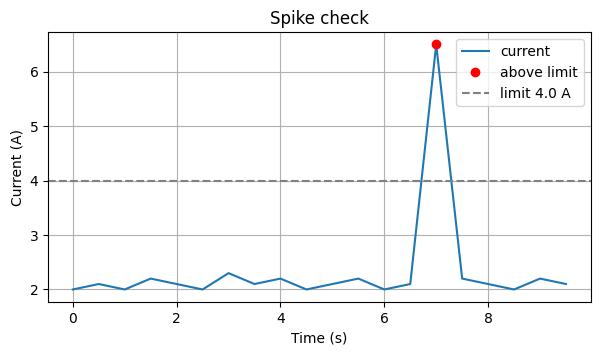

Limit 4.0 A: 1 of 20 readings above, at t = [7.0] s
Saved: spike_check.png


In [19]:
plt.figure(figsize=(7, 3.5))
plt.plot(t, current, label="current")
plt.plot(t[mask], current[mask], "ro", label="above limit")
plt.axhline(limit, color="gray", linestyle="--", label=f"limit {limit} A")
plt.xlabel("Time (s)")
plt.ylabel("Current (A)")
plt.title("Spike check")
plt.grid(True)
plt.legend()
plt.savefig("spike_check.png")
plt.show()

print(f"Limit {limit} A: {mask.sum()} of {len(current)} readings above, at t = {t[mask].tolist()} s")
print("Saved: spike_check.png")


---

## 📝 Core Practice (Exercises 1–8)

Each exercise is a problem. Think about the steps before you code. Each exercise cell starts with `# ✏️ [EXn]` — do not remove this marker.

- **Exercises 1–8:** core in-class practice.
- **Exercises 9 and above:** optional extension; these are not homework.
- At Checkpoint 5, list the exercises you have tested and can explain. This is a self-report, not automatic grading.


### Exercise 1: Column Means with Loops (Easy)

The temperature table below has 12 rows (every 5 minutes) and 3 columns (sensors A, B, C). Using **plain Python loops only**, compute the mean of each column and print it with two decimals.

**Expected output:**
```
Sensor A: mean = 23.79 C
Sensor B: mean = 22.70 C
Sensor C: mean = 23.95 C
```

<details><summary>💡 Hint</summary>

Loop over `col in range(3)`. Inside, loop over the rows and add `row[col]` to a total. Divide by `len(temps)`.
</details>


In [20]:
# ✏️ [EX1]
temps = [
    [22.1, 21.8, 22.4],
    [22.3, 21.9, 22.6],
    [22.6, 22.0, 22.9],
    [22.9, 22.2, 23.1],
    [23.4, 22.5, 23.5],
    [23.8, 22.7, 23.9],
    [24.1, 22.9, 24.2],
    [24.5, 23.0, 24.6],
    [24.7, 23.2, 24.8],
    [24.9, 23.3, 25.0],
    [25.0, 23.4, 25.1],
    [25.2, 23.5, 25.3],
]


### Exercise 2: Column Means with NumPy (Easy)

Repeat Exercise 1 with NumPy. Convert `temps` to an array, print its shape, and print the per-sensor means with two decimals using one call with `axis=0`.

**Expected output:**
```
Shape: (12, 3)
Sensor A: mean = 23.79 C
Sensor B: mean = 22.70 C
Sensor C: mean = 23.95 C
```

<details><summary>💡 Hint</summary>

`a = np.array(temps)`, then `a.mean(axis=0)` gives three values. Loop over them to print with `:.2f`.
</details>


In [21]:
# ✏️ [EX2]
import numpy as np
temps = [
    [22.1, 21.8, 22.4],
    [22.3, 21.9, 22.6],
    [22.6, 22.0, 22.9],
    [22.9, 22.2, 23.1],
    [23.4, 22.5, 23.5],
    [23.8, 22.7, 23.9],
    [24.1, 22.9, 24.2],
    [24.5, 23.0, 24.6],
    [24.7, 23.2, 24.8],
    [24.9, 23.3, 25.0],
    [25.0, 23.4, 25.1],
    [25.2, 23.5, 25.3],
]


### Exercise 3: Beam Deflection mm to m (Easy)

A beam was loaded in steps and its deflection measured in millimetres. Convert the whole deflection column to **metres** with one array multiplication. Print a table of load (N) and deflection (m) with four decimals, then the maximum deflection in metres.

**Expected output:**
```
Load (N)  Deflection (m)
       0          0.0000
     100          0.0004
     200          0.0008
     300          0.0013
     400          0.0017
     500          0.0021
Maximum deflection: 0.0021 m
```

<details><summary>💡 Hint</summary>

`np.array(deflection_mm) * 0.001` converts every value. `np.max` finds the largest.
</details>


In [22]:
# ✏️ [EX3]
import numpy as np
load_n = [0, 100, 200, 300, 400, 500]
deflection_mm = [0.00, 0.42, 0.85, 1.27, 1.70, 2.12]


### Exercise 4: Count Readings Above a Threshold (Medium)

Using the temperature table, count how many readings are above **24.0 °C**: in the whole table, and per sensor. Then print the values above the threshold for sensor A.

**Expected output:**
```
Readings above 24.0 C: 12 of 36
Per sensor: [6 0 6]
Sensor A values above threshold: 24.1 24.5 24.7 24.9 25.0 25.2
```

<details><summary>💡 Hint</summary>

`mask = a > 24.0`. `mask.sum()` counts everything; `mask.sum(axis=0)` counts per column; `a[:, 0][mask[:, 0]]` selects sensor A values.
</details>


In [23]:
# ✏️ [EX4]
import numpy as np
temps = [
    [22.1, 21.8, 22.4],
    [22.3, 21.9, 22.6],
    [22.6, 22.0, 22.9],
    [22.9, 22.2, 23.1],
    [23.4, 22.5, 23.5],
    [23.8, 22.7, 23.9],
    [24.1, 22.9, 24.2],
    [24.5, 23.0, 24.6],
    [24.7, 23.2, 24.8],
    [24.9, 23.3, 25.0],
    [25.0, 23.4, 25.1],
    [25.2, 23.5, 25.3],
]
threshold = 24.0


### Exercise 5: Time of Maximum Current (Medium)

A motor current was logged every 0.5 s. Find the maximum current, the **position** of that maximum and the **time** at which it happened. Also print the mean current *without* that sample.

**Expected output:**
```
Maximum current: 6.50 A
Position: 14, time: 7.0 s
Mean with peak:    2.325 A
Mean without peak: 2.105 A
```

<details><summary>💡 Hint</summary>

`np.argmax(current)` gives the index of the largest value. Use it on the time array too. A mask `current < current.max()` removes the peak.
</details>


In [24]:
# ✏️ [EX5]
import numpy as np
time_s = [0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5,
          5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5]
current_a = [2.0, 2.1, 2.0, 2.2, 2.1, 2.0, 2.3, 2.1, 2.2, 2.0,
             2.1, 2.2, 2.0, 2.1, 6.5, 2.2, 2.1, 2.0, 2.2, 2.1]


### Exercise 6: Moving Average with a Loop (Medium)

Smooth the motor current with a **3-point moving average**: for every position `i`, average `current[i]`, `current[i+1]` and `current[i+2]`. Use a loop over the NumPy array and store the results in a list. Print how many averages you get, the largest one with its centre time, and all averages on one line with two decimals.

**Expected output:**
```
Number of averages: 18
Largest average: 3.60 A at centre time 7.0 s
All: 2.03 2.10 2.10 2.10 2.13 2.13 2.20 2.10 2.10 2.10 2.10 2.10 3.53 3.60 3.60 2.10 2.10 2.10
```

<details><summary>💡 Hint</summary>

There are `len(current) - 2` windows. `window = current[i:i+3]` is a slice; `window.mean()` averages it. The centre of window `i` is `t[i+1]`.
</details>


In [25]:
# ✏️ [EX6]
import numpy as np
time_s = [0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5,
          5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5]
current_a = [2.0, 2.1, 2.0, 2.2, 2.1, 2.0, 2.3, 2.1, 2.2, 2.0,
             2.1, 2.2, 2.0, 2.1, 6.5, 2.2, 2.1, 2.0, 2.2, 2.1]


### Exercise 7: Plot One Sensor (Medium)

Plot sensor A of the temperature table against time in minutes (0, 5, …, 55). Add axis labels with units, a title and a grid. Save the figure as `sensor_a.png` and print a confirmation that the file exists.

**Expected output (plus the figure):**
```
Saved sensor_a.png: True
```

<details><summary>💡 Hint</summary>

`minutes = np.arange(0, 60, 5)`; `plt.plot(minutes, a[:, 0])`. Call `plt.savefig` **before** `plt.show()`. Check with `os.path.exists`.
</details>


In [26]:
# ✏️ [EX7]
import numpy as np
import matplotlib.pyplot as plt
import os
temps = [
    [22.1, 21.8, 22.4],
    [22.3, 21.9, 22.6],
    [22.6, 22.0, 22.9],
    [22.9, 22.2, 23.1],
    [23.4, 22.5, 23.5],
    [23.8, 22.7, 23.9],
    [24.1, 22.9, 24.2],
    [24.5, 23.0, 24.6],
    [24.7, 23.2, 24.8],
    [24.9, 23.3, 25.0],
    [25.0, 23.4, 25.1],
    [25.2, 23.5, 25.3],
]


### Exercise 8: Plot Three Sensors with a Legend (Medium)

Plot all three sensors on one figure with a legend (`Sensor A`, `Sensor B`, `Sensor C`), labels with units, a title and a grid. Save it as `sensors.png`. Then print which sensor has the largest final reading.

**Expected output (plus the figure):**
```
Saved sensors.png: True
Largest final reading: Sensor C at 25.3 C
```

<details><summary>💡 Hint</summary>

Loop over `col in range(3)` and call `plt.plot(minutes, a[:, col], label=...)`. `plt.legend()` after the loop. `np.argmax(a[-1, :])` finds the largest value in the last row.
</details>


In [27]:
# ✏️ [EX8]
import numpy as np
import matplotlib.pyplot as plt
import os
temps = [
    [22.1, 21.8, 22.4],
    [22.3, 21.9, 22.6],
    [22.6, 22.0, 22.9],
    [22.9, 22.2, 23.1],
    [23.4, 22.5, 23.5],
    [23.8, 22.7, 23.9],
    [24.1, 22.9, 24.2],
    [24.5, 23.0, 24.6],
    [24.7, 23.2, 24.8],
    [24.9, 23.3, 25.0],
    [25.0, 23.4, 25.1],
    [25.2, 23.5, 25.3],
]


---
### Checkpoint 5 of 5 — Practice reflection (target 04:45)

After Exercises 1–8, edit `practiced_exercises` in the next cell.
List only the exercise numbers whose results you have tested and whose steps you can explain.
Leave the list empty until you have done that work. This is your explicit self-report;
the tool does not inspect or grade your solution and does not count execution history.

**Türkçe:** Bu liste öz değerlendirmedir. Hücreyi çalıştırmak tek başına yeterli değildir;
sonucu kontrol et ve çözüm adımlarını açıklayabildiğinden emin ol.


In [ ]:
# Add an exercise number only after testing and explaining your own work.
# Example: [1, 2] records your reflection about Exercises 1 and 2.
# Türkçe: Bu liste öz değerlendirmedir; kodunuzun doğruluğunu otomatik ölçmez.
practiced_exercises = []
exercise_checkpoint(5, practiced_exercises, expected=8)
show_progress_summary()


---
## 🌟 Optional Extensions (Exercises 9–12)

Exercises 9 and above are optional enrichment. Exercise 12 is aimed at second-year students. Stop here if the five-hour class has ended.


### Exercise 9: Normalise Each Column (z-score) (Medium)

Normalise the temperature table so that each **column** has mean 0 and standard deviation 1: `z = (a - mean) / std` with the mean and std computed per column (`axis=0`). Print the first two rows of `z` with two decimals and confirm the new column means are 0.

**Expected output:**
```
Row 0:  -1.59  -1.54  -1.57
Row 1:  -1.40  -1.37  -1.37
Column means are 0: True
Column stds are 1:  True
```

<details><summary>💡 Hint</summary>

`a.mean(axis=0)` and `a.std(axis=0)` are arrays of three values. NumPy subtracts and divides them column by column automatically (broadcasting).
</details>


In [29]:
# ✏️ [EX9]
import numpy as np
temps = [
    [22.1, 21.8, 22.4],
    [22.3, 21.9, 22.6],
    [22.6, 22.0, 22.9],
    [22.9, 22.2, 23.1],
    [23.4, 22.5, 23.5],
    [23.8, 22.7, 23.9],
    [24.1, 22.9, 24.2],
    [24.5, 23.0, 24.6],
    [24.7, 23.2, 24.8],
    [24.9, 23.3, 25.0],
    [25.0, 23.4, 25.1],
    [25.2, 23.5, 25.3],
]


### Exercise 10: Detect Spikes with |diff| > k·std (Medium)

Detect spikes in the motor current: compute the differences between neighbours with `np.diff(current)`, then flag every step where `abs(diff) > k * std(diff)` with `k = 2.0`. Print the flagged positions and their times, and the number of flags.

**Expected output:**
```
Threshold: 2.838 A
Flagged steps: [13, 14]
  step 13: 6.5 s -> 7.0 s, change +4.40 A
  step 14: 7.0 s -> 7.5 s, change -4.30 A
Number of flags: 2
```

<details><summary>💡 Hint</summary>

`np.diff` returns 19 values for 20 samples; difference `i` is between samples `i` and `i+1`. Build a mask on `np.abs(diff)` and use `np.where`.
</details>


In [30]:
# ✏️ [EX10]
import numpy as np
time_s = [0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5,
          5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5]
current_a = [2.0, 2.1, 2.0, 2.2, 2.1, 2.0, 2.3, 2.1, 2.2, 2.0,
             2.1, 2.2, 2.0, 2.1, 6.5, 2.2, 2.1, 2.0, 2.2, 2.1]
k = 2.0


### Exercise 11: Trapezoid Integration of a Velocity Log (Medium)

A vehicle's speed was logged every 0.5 s. Estimate the distance travelled with the **trapezoid rule** in a loop: each step adds `(v[i] + v[i+1]) / 2 * (t[i+1] - t[i])`. Print the distance with three decimals, then compare with NumPy's `np.trapezoid` (older versions call it `np.trapz`).

**Expected output:**
```
Loop distance:  12.900 m
NumPy distance: 12.900 m
Agree: True
```

<details><summary>💡 Hint</summary>

Loop `for i in range(len(t) - 1)`. Use `trap = getattr(np, "trapezoid", None) or np.trapz` so the code works with any NumPy version.
</details>


In [31]:
# ✏️ [EX11]
import numpy as np
t_s = [0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]
v_ms = [0.0, 0.5, 1.1, 1.8, 2.4, 3.0, 3.4, 3.7, 3.9, 4.0, 4.0]


### Exercise 12: Calibration Line Fit (Challenge)

A pressure sensor gives a voltage for known pressures. Fit a straight line `voltage = slope * pressure + intercept` with `np.polyfit(x, y, 1)`. Print the slope (V/kPa, five decimals) and intercept (V, three decimals), the residual for each point (three decimals) and the largest absolute residual. Plot the points and the fitted line, and save `calibration.png`. Then use the fit to convert a reading of 1.75 V back to pressure.

**Expected output (plus the figure):**
```
Slope: 0.00493 V/kPa
Intercept: 0.525 V
      0 kPa residual -0.005 V
    100 kPa residual +0.012 V
    200 kPa residual -0.022 V
    300 kPa residual +0.015 V
    400 kPa residual +0.012 V
    500 kPa residual -0.012 V
Largest |residual|: 0.022 V
1.75 V -> 248.3 kPa
Saved calibration.png: True
```

<details><summary>💡 Hint</summary>

`slope, intercept = np.polyfit(x, y, 1)`. Residuals: `y - (slope * x + intercept)`. Inverse: `(v - intercept) / slope`. Plot data with `"o"` and the line with a regular `plt.plot`.
</details>


In [32]:
# ✏️ [EX12]
import numpy as np
import matplotlib.pyplot as plt
import os
pressure_kpa = [0, 100, 200, 300, 400, 500]
voltage_v = [0.52, 1.03, 1.49, 2.02, 2.51, 2.98]
reading_v = 1.75


### Bridge Exercise: Preview of the capstone

Next week you will build the **capstone sensor report**: read a log, compute per-sensor statistics, check limits and save a report.

As a preview, write a CSV file called `data.csv` from the string below, read it back into a NumPy array, compute the mean of each sensor and print a **one-line report**.

```python
csv_text = """minute,sensor_a,sensor_b,sensor_c
0,22.1,21.8,22.4
5,22.3,21.9,22.6
10,22.6,22.0,22.9
15,22.9,22.2,23.1
20,23.4,22.5,23.5
"""
```

**Expected output:**
```
Report: 5 rows, sensor means A=22.66 B=22.08 C=22.90 C
```

<details><summary>💡 Hint</summary>

Write with `open("data.csv", "w")`. Read with `np.loadtxt(..., delimiter=",", skiprows=1)`. The sensors are columns 1 to 3: `data[:, 1:]`.
</details>


In [33]:
# ✏️ [EXBridge]
import numpy as np

csv_text = """minute,sensor_a,sensor_b,sensor_c
0,22.1,21.8,22.4
5,22.3,21.9,22.6
10,22.6,22.0,22.9
15,22.9,22.2,23.1
20,23.4,22.5,23.5
"""


## Worked solutions and study support

Try each problem first. Then compare your reasoning and test cases with the complete
[Week 13 worked solutions](../solutions/Week_13_Solutions.ipynb).
The solution notebook includes every core exercise, optional exercise, and this week's bridge when present.

If you are using Colab, [open the published solution notebook](https://colab.research.google.com/github/ArifSolmaz/courses/blob/main/fall/cp1/solutions/Week_13_Solutions.ipynb).
Open it in a separate runtime. Running a solution first should not supply hidden variables to your own work.

**Türkçe:** Önce kendi çözümünü dene. Sonra adımları ve testleri karşılaştır; çözümü kapatıp farklı bir örneği kendin çöz.

[Simple course guide](../STUDY_GUIDE.md) · [All worked solutions](../solutions/README.md)
